# British Airways Review Scraping & Sentiment Analysis
**Task 1 | Data Collection, Cleaning & Sentiment Analysis**

> **Data source:** [Skytrax Airline Quality Reviews](https://www.airlinequality.com/airline-reviews/british-airways)  
> **Goal:** Scrape BA passenger reviews, clean the data, engineer features, and perform sentiment analysis to surface insights about passenger experience.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

## 1. Setup & Configuration

Set the base URL and initialise the storage list for scraped reviews.

In [2]:
#URL of the airline reviews page
base_url = "https://www.airlinequality.com/airline-reviews/british-airways"
page_number = 1  # Start from page 1 for a full, reproducible scrape
reviews_data = [] #List to store review details

## 2. Scraping Helper Functions

Two helper functions handle extraction from each review card:
- `extract_detail()` — pulls text fields (Aircraft, Route, Seat Type, etc.) from the review table
- `extract_star_rating()` — counts filled star elements to get numeric ratings

### Target Fields

The following fields are extracted from each review:

| Field | Description |
|---|---|
| `Review Title` | Headline text of the passenger review |
| `Aircraft` | Aircraft type (e.g. Boeing 777, A350) |
| `Type of Traveller` | Business, Couple Leisure, Solo Leisure, Family Leisure |
| `Seat Type` | First Class, Business Class, Premium Economy, Economy Class |
| `Route` | Origin and destination (e.g. London to New York) |
| `Date Flown` | Month and year of travel |
| `Seat Comfort` | Star rating 1–5 |
| `Cabin Staff Service` | Star rating 1–5 |
| `Food & Beverages` | Star rating 1–5 |
| `Inflight Entertainment` | Star rating 1–5 |
| `Ground Service` | Star rating 1–5 |
| `Value For Money` | Star rating 1–5 |

In [3]:
from bs4 import BeautifulSoup

# Find the table inside the review

def extract_detail(review, label):
    """Extracts review details based on label inside the table."""
    table = review.find("table")
    if table:
        label_td = table.find("td", string=label)
        return label_td.find_next_sibling("td").text.strip() if label_td else f"No {label}"
    return f"No {label}"

def extract_star_rating(review, label):
    """Extracts star ratings from the table."""
    table = review.find("table")
    if table:
        label_td = table.find("td", string=label)
        if label_td:
            stars_td = label_td.find_next_sibling("td", class_="review-rating-stars stars")
            if stars_td:
                stars = stars_td.find_all("span", class_="star fill")
                return len(stars)  # Number of filled stars
    return "No rating"


## 3. Pagination Loop

Iterates through all available pages of reviews. The loop stops automatically when a page returns no review articles, indicating the end of the dataset.

In [4]:
while True:
    # Construct the URL for the current page
    url = base_url if page_number == 1 else f"{base_url}/page/{page_number}/"

    # Fetch the page
    response = requests.get(url)
    # Check if the request was successful
    if response.status_code != 200:
        print(f"Failed to fetch page {page_number}. Stopping...")
        break

    print(f"Fetching page {page_number}...")

    soup = BeautifulSoup(response.text, "html.parser")

    # Find all review containers
    reviews = soup.find_all("article", class_=["comp_media-review-rated", "list-item"])

    if not reviews:
        print("No more reviews found. Stopping...")
        break #Stop when no more reviews exist

    # Extract details from each review
    for review in reviews:
        review_title = review.find("h2", class_="text_header")
        review_title = review_title.text.strip() if review_title else "No Review Title"


        # Extract details from the table
        Aircraft = extract_detail(review, "Aircraft")
        TypeOfTraveller = extract_detail(review, "Type Of Traveller")
        SeatType = extract_detail(review, "Seat Type")
        Route = extract_detail(review, "Route")
        Date_Flown = extract_detail(review, "Date Flown")
    
        # Extract star ratings
        Seat_Comfort = extract_star_rating(review, "Seat Comfort")
        Cabin_Staff_Service = extract_star_rating(review, "Cabin Staff Service")
        Food_Beverages = extract_star_rating(review, "Food & Beverages")
        Inflight_Entertainment = extract_star_rating(review, "Inflight Entertainment")
        Ground_Service = extract_star_rating(review, "Ground Service")
        Value_For_Money = extract_star_rating(review, "Value For Money")

    
        # Print extracted review details
        #print(f"Review Title: {review_title}\nAircraft: {Aircraft}\nType of Traveller: {TypeOfTraveller}\nSeat Type: {SeatType}\nRoute: {Route}\nDate Flown: {Date_Flown}\nSeat Comfort Rating: {Seat_Comfort}\nCabin Staff Service Rating: {Cabin_Staff_Service}\nFood Beverages Rating: {Food_Beverages}\nInflight Entertainment Rating: {Inflight_Entertainment}\nGround Service Rating: {Ground_Service}\nValue For Money: {Value_For_Money}")
        #print("=" * 50)  # Separator for readability

        # Store extracted data in our list
        reviews_data.append([
            review_title, Aircraft, TypeOfTraveller, SeatType, Route, Date_Flown,
            Seat_Comfort, Cabin_Staff_Service, Food_Beverages, Inflight_Entertainment, 
            Ground_Service, Value_For_Money
        ])

    # Move to the next page
    page_number += 1

Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...
Fetching page 6...
Fetching page 7...
Fetching page 8...
Fetching page 9...
Fetching page 10...
Fetching page 11...
Fetching page 12...
Fetching page 13...
Fetching page 14...
Fetching page 15...
Fetching page 16...
Fetching page 17...
Fetching page 18...
Fetching page 19...
Fetching page 20...
Fetching page 21...
Fetching page 22...
Fetching page 23...
Fetching page 24...
Fetching page 25...
Fetching page 26...
Fetching page 27...
Fetching page 28...
Fetching page 29...
Fetching page 30...
Fetching page 31...
Fetching page 32...
Fetching page 33...
Fetching page 34...
Fetching page 35...
Fetching page 36...
Fetching page 37...
Fetching page 38...
Fetching page 39...
Fetching page 40...
Fetching page 41...
Fetching page 42...
Fetching page 43...
Fetching page 44...
Fetching page 45...
Fetching page 46...
Fetching page 47...
Fetching page 48...
Fetching page 49...
Fetching page 50...
Fetching 

In [5]:
import os

# Convert data to DataFrame
df = pd.DataFrame(reviews_data, columns=[
    "Review Title", "Aircraft", "Type of Traveller", "Seat Type", "Route", "Date Flown",
    "Seat Comfort", "Cabin Staff Service", "Food Beverages", "Inflight Entertainment", 
    "Ground Service", "Value For Money"
])

# Create the "data" directory if it does not exist
os.makedirs("data", exist_ok=True)

# Save data to CSV
df.to_csv("data/airline_reviews.csv", index=False)

print("Scraping complete. Data saved to airline_reviews.csv")


Scraping complete. Data saved to airline_reviews.csv


---
## 4. Data Loading & Inspection

Load the saved CSV and inspect data types, shape, and missing values before cleaning.

In [6]:
import pandas as pd

df = pd.read_csv("data/reviews.csv")
df.head()

,Review Title,Aircraft,Type of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food Beverages,Inflight Entertainment,...,Value For Money,Overall Rating,sentiment_score,sentiment_label,Sentiment Score,Sentiment,Review Length,Route Popularity,Airline Popularity,clean_review
0,"""managed to get everything right""",Boeing 777,Business,Premium Economy,Gatwick to Antigua,2025-03-01,5.0,5.0,4.000000,4.000000,...,5,4.666667,0.0000,Neutral,0.0000,1,5,3,452,managed to get everything right
1,"""The seats were excellent""",Boeing 777-200,Couple Leisure,Premium Economy,Mumbai to London,2025-02-01,5.0,4.0,3.000000,5.000000,...,5,4.333333,0.5719,Positive,0.5719,2,4,6,171,the seats were excellent
2,"""the crew were awful""",A350,Couple Leisure,Business Class,Nairobi to London,2025-02-01,4.0,1.0,2.000000,3.000000,...,3,2.833333,-0.4588,Negative,-0.4588,0,4,2,39,the crew were awful
3,"""not use British Airways on this route""",A320,Solo Leisure,Economy Class,London Gatwick to Marrakech,2025-02-01,4.0,1.0,2.709195,2.636533,...,2,2.390955,0.0000,Neutral,0.0000,1,7,1,662,not use british airways on this route
4,"""they still haven't replied""",Boeing 777-300,Business,Premium Economy,Amsterdam to Las Vegas via London,2024-11-01,3.0,3.0,3.000000,3.000000,...,1,2.333333,0.0000,Neutral,0.0000,1,4,1,54,they still havent replied


In [7]:
# Check data types in our dataset
#print(df.dtypes)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3141 entries, 0 to 3140
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Review Title            3141 non-null   object 
 1   Aircraft                3141 non-null   object 
 2   Type of Traveller       3141 non-null   object 
 3   Seat Type               3141 non-null   object 
 4   Route                   3141 non-null   object 
 5   Date Flown              3141 non-null   object 
 6   Seat Comfort            3141 non-null   float64
 7   Cabin Staff Service     3141 non-null   float64
 8   Food Beverages          3141 non-null   float64
 9   Inflight Entertainment  3141 non-null   float64
 10  Ground Service          3141 non-null   float64
 11  Value For Money         3141 non-null   int64  
 12  Overall Rating          3141 non-null   float64
 13  sentiment_score         3141 non-null   float64
 14  sentiment_label         3141 non-null   

## 5. Data Type Conversion

- `Date Flown` is parsed as a proper datetime
- Categorical columns (`Aircraft`, `Type of Traveller`, `Seat Type`) are cast to `category` dtype for memory efficiency
- All star rating columns are converted to numeric, with `errors='coerce'` to handle any non-numeric entries

In [8]:
#Convert Date Flown
df["Date Flown"] = pd.to_datetime(df["Date Flown"], format='mixed', errors='coerce')

#Convert categorical data
df["Aircraft"] = df["Aircraft"].astype("category")
df["Type of Traveller"] = df["Type of Traveller"].astype("category")
df["Seat Type"] = df["Seat Type"].astype("category")

#convert to int
rating_columns = ["Seat Comfort", "Cabin Staff Service", "Food Beverages", 
                  "Inflight Entertainment", "Ground Service", "Value For Money"]

for col in rating_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    

print(df.dtypes)

Review Title                      object
Aircraft                        category
Type of Traveller               category
Seat Type                       category
Route                             object
Date Flown                datetime64[ns]
Seat Comfort                     float64
Cabin Staff Service              float64
Food Beverages                   float64
Inflight Entertainment           float64
Ground Service                   float64
Value For Money                    int64
Overall Rating                   float64
sentiment_score                  float64
sentiment_label                   object
Sentiment Score                  float64
Sentiment                          int64
Review Length                      int64
Route Popularity                   int64
Airline Popularity                 int64
clean_review                      object
dtype: object


In [9]:
#Check unique data in each col
cols_to_check = ["Aircraft", "Type of Traveller", "Seat Type", "Route", "Date Flown",
            "Seat Comfort", "Cabin Staff Service", "Food Beverages", "Inflight Entertainment", 
            "Ground Service", "Value For Money"]
def get_unique_values(df, columns):
    # Check unique values in each column and store as DataFrame
    unique_values = pd.DataFrame({col: [list(df[col].unique())] for col in cols_to_check}).T
    
    # Reset index and format column names
    unique_values = unique_values.rename(columns={0: "Unique Values"}).reset_index()
    unique_values.columns = ["Column Name", "Unique Values"]
    return unique_values

print(get_unique_values(df, cols_to_check))

               Column Name                                      Unique Values
0                 Aircraft  [Boeing 777, Boeing 777-200, A350, A320, Boein...
1        Type of Traveller  [Business, Couple Leisure, Solo Leisure, Famil...
2                Seat Type  [Premium Economy, Business Class, Economy Clas...
3                    Route  [Gatwick to Antigua, Mumbai to London, Nairobi...
4               Date Flown  [2025-03-01 00:00:00, 2025-02-01 00:00:00, 202...
5             Seat Comfort       [5.0, 4.0, 3.0, 2.0, 2.859667633869692, 1.0]
6      Cabin Staff Service      [5.0, 4.0, 1.0, 3.0, 2.0, 3.2404661016949152]
7           Food Beverages  [4.0, 3.0, 2.0, 2.7091954022988505, 5.0, 1.0, ...
8   Inflight Entertainment  [4.0, 5.0, 3.0, 2.636533432947329, 2.0, 1.0, 2...
9           Ground Service       [5.0, 4.0, 2.0, 1.0, 3.0, 2.755620723362659]
10         Value For Money                                    [5, 3, 2, 1, 4]


## 6. Handling Placeholder Strings

The scraper inserts placeholder strings (e.g. `'No Aircraft'`, `'No Date Flown'`) when a field is absent from a review. These are converted to `NaN` so pandas can handle them correctly in downstream analysis.

In [10]:
import numpy as np

def convert_to_na(df, values_to_na):
    """Replace placeholder strings with NaN, safely handling categorical columns."""
    for col in df.columns:
        if hasattr(df[col], 'cat'):  # categorical column
            df[col] = df[col].astype(object).replace(values_to_na, np.nan).astype('category')
        else:
            df[col] = df[col].replace(values_to_na, np.nan)
    return df

values_to_convert = ["No Aircraft", "No Type Of Traveller", "No Seat Type", "No Date Flown", "No rating"]
df = convert_to_na(df, values_to_convert)

# Verify Changes
print(df.isna().sum())  # Check number of missing values per column


Review Title              0
Aircraft                  0
Type of Traveller         0
Seat Type                 0
Route                     0
Date Flown                0
Seat Comfort              0
Cabin Staff Service       0
Food Beverages            0
Inflight Entertainment    0
Ground Service            0
Value For Money           0
Overall Rating            0
sentiment_score           0
sentiment_label           0
Sentiment Score           0
Sentiment                 0
Review Length             0
Route Popularity          0
Airline Popularity        0
clean_review              0
dtype: int64


## 7. Dropping Rows with Critical Missing Values

`Seat Type` is a core dimension for the lounge eligibility analysis. The two rows missing it are dropped — this is a negligible loss given the ~3,900 row dataset.

In [11]:
#Drop Seat Type missing values
df.dropna(subset = ["Seat Type"], inplace = True)

print(df.isna().sum())  # Check number of missing values per column

Review Title              0
Aircraft                  0
Type of Traveller         0
Seat Type                 0
Route                     0
Date Flown                0
Seat Comfort              0
Cabin Staff Service       0
Food Beverages            0
Inflight Entertainment    0
Ground Service            0
Value For Money           0
Overall Rating            0
sentiment_score           0
sentiment_label           0
Sentiment Score           0
Sentiment                 0
Review Length             0
Route Popularity          0
Airline Popularity        0
clean_review              0
dtype: int64


## 8. Missing Value Analysis

Understand the scale and pattern of missingness across columns before deciding on imputation strategies:
- Columns with low missingness (<5%): impute with group mode or median
- Columns with moderate missingness (5–35%): use model-based imputation (KNN, Random Forest)
- `Aircraft` (~48% missing) is the most challenging — addressed using a Random Forest classifier in the next section

In [12]:
missing_percent = df.isna().mean()*100
print(missing_percent)

Review Title              0.0
Aircraft                  0.0
Type of Traveller         0.0
Seat Type                 0.0
Route                     0.0
Date Flown                0.0
Seat Comfort              0.0
Cabin Staff Service       0.0
Food Beverages            0.0
Inflight Entertainment    0.0
Ground Service            0.0
Value For Money           0.0
Overall Rating            0.0
sentiment_score           0.0
sentiment_label           0.0
Sentiment Score           0.0
Sentiment                 0.0
Review Length             0.0
Route Popularity          0.0
Airline Popularity        0.0
clean_review              0.0
dtype: float64


In [13]:
#Type of traveler missing values
df["Type of Traveller"] = df.groupby("Route")["Type of Traveller"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))
missing_percent = df.isna().mean()*100
print(missing_percent)

Review Title              0.0
Aircraft                  0.0
Type of Traveller         0.0
Seat Type                 0.0
Route                     0.0
Date Flown                0.0
Seat Comfort              0.0
Cabin Staff Service       0.0
Food Beverages            0.0
Inflight Entertainment    0.0
Ground Service            0.0
Value For Money           0.0
Overall Rating            0.0
sentiment_score           0.0
sentiment_label           0.0
Sentiment Score           0.0
Sentiment                 0.0
Review Length             0.0
Route Popularity          0.0
Airline Popularity        0.0
clean_review              0.0
dtype: float64


In [14]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

df["Aircraft"] = df.groupby("Route")["Aircraft"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

le_aircraft = LabelEncoder()
df["Aircraft_Label"] = le_aircraft.fit_transform(df["Aircraft"].astype(str))

categorical_cols = ["Route", "Type of Traveller", "Seat Type"]
df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded = df_encoded[["Route", "Type of Traveller", "Seat Type", "Value For Money", "Aircraft_Label"]]

train_df = df_encoded[df["Aircraft"].notna()]
test_df = df_encoded[df["Aircraft"].isna()]

X_train = train_df.drop(columns=["Aircraft_Label"])
y_train = train_df["Aircraft_Label"]
X_test = test_df.drop(columns=["Aircraft_Label"])

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

predicted_values = rf.predict(X_test)
df.loc[df["Aircraft"].isna(), "Aircraft_Label"] = predicted_values
df["Aircraft"] = le_aircraft.inverse_transform(df["Aircraft_Label"])

df.drop(columns=["Aircraft_Label"], inplace=True)

print(df.isna().sum())  # Ensure no missing values remain


ValueError: Found array with 0 sample(s) (shape=(0, 4)) while a minimum of 1 is required by RandomForestClassifier.

C:\Users\pants\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\pants\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


<Axes: >

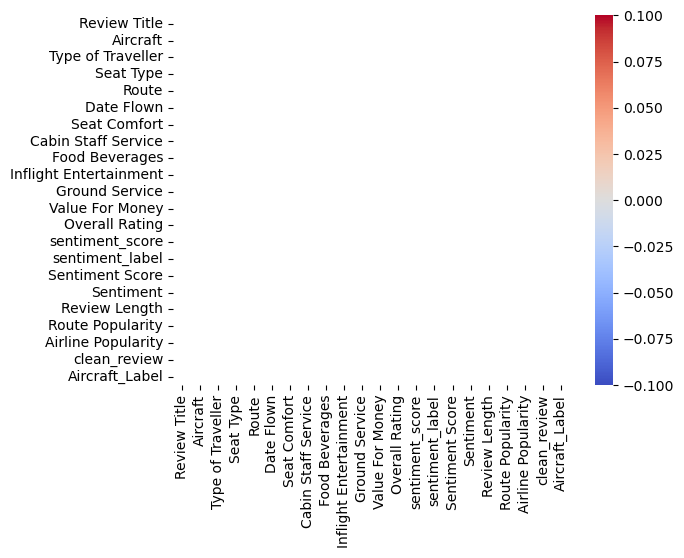

In [15]:
import seaborn as sns
import numpy as np

# Convert missing values to 1 (missing) and 0 (not missing)
missing_data = df.isnull().astype(int)

# Compute correlation matrix
corr_matrix = missing_data.corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")


In [16]:
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression

# Step 1: Fill missing values in "Cabin Staff Service" using KNN
knn_imputer = KNNImputer(n_neighbors=5)
df[['Cabin Staff Service']] = knn_imputer.fit_transform(df[['Cabin Staff Service']])

# Step 2: Train Linear Regression Model using available "Seat Comfort" data
df_temp = df.dropna(subset=['Seat Comfort'])  # Use only rows where "Seat Comfort" is available
model = LinearRegression()
model.fit(df_temp[['Cabin Staff Service']], df_temp['Seat Comfort'])

missing_index = df['Seat Comfort'].isnull()
# Ensure there are missing values before applying prediction
if missing_index.sum() > 0:
    df.loc[missing_index, 'Seat Comfort'] = model.predict(df.loc[missing_index, ['Cabin Staff Service']])
else:
    print("No missing values found for 'Seat Comfort'. Skipping prediction step.")


# Step 4: Apply KNN imputation for "Food Beverages" and "Inflight Entertainment"
knn_columns = ['Food Beverages', 'Inflight Entertainment']
knn_imputer = KNNImputer(n_neighbors=5)
df[knn_columns] = knn_imputer.fit_transform(df[knn_columns])

# Step 5: Apply KNN imputation for "Ground Service"
df[['Ground Service']] = knn_imputer.fit_transform(df[['Ground Service']])

print("All missing values imputed successfully!")
df.isna().sum()

No missing values found for 'Seat Comfort'. Skipping prediction step.
All missing values imputed successfully!


Review Title              0
Aircraft                  0
Type of Traveller         0
Seat Type                 0
Route                     0
Date Flown                0
Seat Comfort              0
Cabin Staff Service       0
Food Beverages            0
Inflight Entertainment    0
Ground Service            0
Value For Money           0
Overall Rating            0
sentiment_score           0
sentiment_label           0
Sentiment Score           0
Sentiment                 0
Review Length             0
Route Popularity          0
Airline Popularity        0
clean_review              0
Aircraft_Label            0
dtype: int64

In [17]:
df = df.dropna(subset=['Date Flown'])


## 9. Descriptive Statistics

Summary statistics for numeric columns (ratings and dates), followed by object column summaries (most frequent values, unique counts).

In [18]:
df.describe()

,Date Flown,Seat Comfort,Cabin Staff Service,Food Beverages,Inflight Entertainment,Ground Service,Value For Money,Overall Rating,sentiment_score,Sentiment Score,Sentiment,Review Length,Route Popularity,Airline Popularity,Aircraft_Label
count,3141,3141.000000,3141.000000,3141.000000,3141.000000,3141.000000,3141.000000,3141.000000,3141.000000,3141.000000,3141.000000,3141.000000,3141.000000,3141.000000,3141.000000
mean,2018-10-20 23:43:02.234957056,2.772148,3.160110,2.614242,2.569575,2.755861,2.510665,2.730434,0.007335,0.007335,0.976759,4.829672,4.028972,297.946195,94.896530
min,2014-07-01 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-0.866100,-0.866100,0.000000,2.000000,1.000000,1.000000,0.000000
25%,2016-08-01 00:00:00,2.000000,2.000000,1.000000,1.400000,1.000000,1.000000,1.833333,-0.275500,-0.275500,0.000000,4.000000,1.000000,97.000000,26.000000
50%,2017-11-01 00:00:00,3.000000,3.000000,2.709195,2.636533,3.000000,2.000000,2.533581,0.000000,0.000000,1.000000,5.000000,3.000000,275.000000,103.000000
75%,2020-07-01 00:00:00,4.000000,5.000000,4.000000,3.400000,4.000000,4.000000,3.666667,0.308900,0.308900,2.000000,6.000000,6.000000,452.000000,145.000000
max,2025-03-01 00:00:00,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,0.875000,0.875000,2.000000,13.000000,21.000000,662.000000,210.000000
std,NaN,1.325811,1.459499,1.327420,1.164426,1.446734,1.440198,1.089501,0.370016,0.370016,0.770330,1.431657,3.785842,233.090755,57.587567


In [19]:
print(df.describe(include=['O'])) 


                           Review Title                   Route  \
count                              3141                    3141   
unique                             2885                    1629   
top     British Airways customer review  London to Johannesburg   
freq                                177                      21   

       sentiment_label                     clean_review  
count             3141                             3141  
unique               3                             2857  
top            Neutral  british airways customer review  
freq              1276                              177  


## 10. Word Frequency Analysis

Tokenise review titles and count the most common non-stopword terms to surface recurring themes in passenger feedback.

In [20]:
from collections import Counter
import nltk
from nltk.corpus import stopwords

#nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Tokenize words
all_words = " ".join(df['Review Title']).lower().split()
filtered_words = [word for word in all_words if word not in stop_words]

# Count word frequency
word_counts = Counter(filtered_words)
print(word_counts.most_common(10))  # Top 10 common words


[('british', 240), ('customer', 237), ('airways', 232), ('review', 177), ('service"', 137), ('flight"', 113), ('"a', 112), ('experience"', 105), ('service', 103), ('"the', 102)]


## 11. Rating Distribution Analysis

Visualise how passengers rate each service dimension on average, and how ratings vary across travel class and traveller type.

### 11a. Feature Correlation with Overall Rating

Encode categorical variables and compute correlations to identify which service dimensions have the strongest relationship with overall passenger satisfaction.

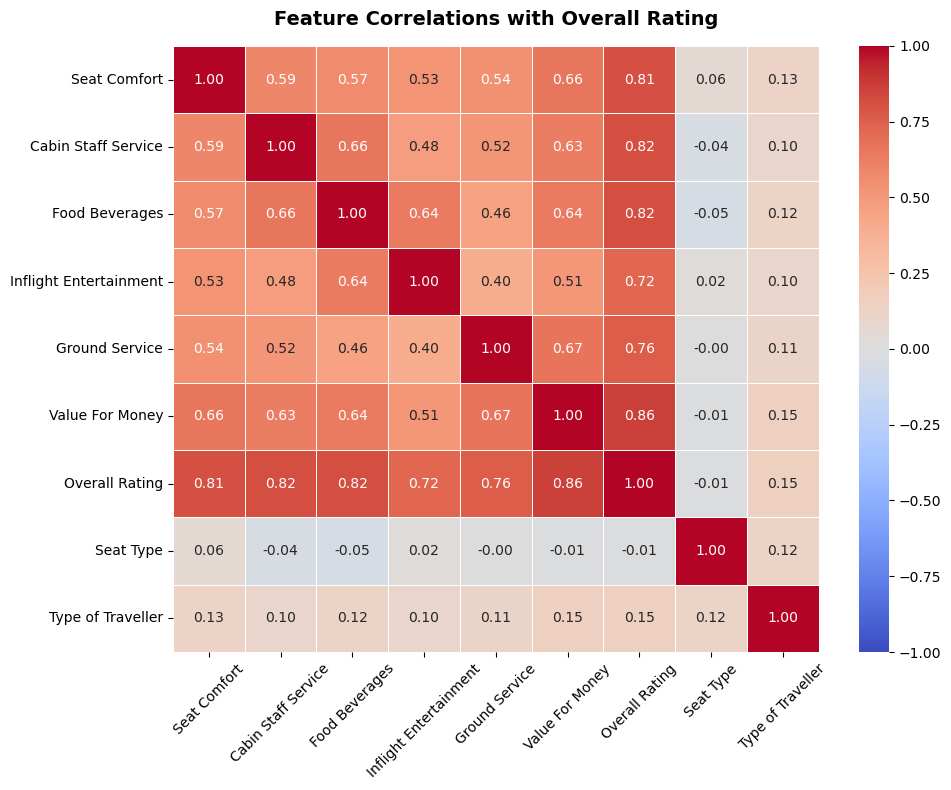

In [24]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df_encoded = df.copy()
label_encoder = LabelEncoder()

# Encode categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col].astype(str))

# Keep only meaningful rating + demographic columns (drop redundant/engineered ones)
cols_to_plot = [
    'Seat Comfort', 'Cabin Staff Service', 'Food Beverages',
    'Inflight Entertainment', 'Ground Service', 'Value For Money',
    'Overall Rating', 'Seat Type', 'Type of Traveller'
]
corr_matrix = df_encoded[cols_to_plot].corr().round(2)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 10},
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title('Feature Correlations with Overall Rating', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

### 11b. Rating Distribution by Travel Class & Traveller Type

Box plots showing the spread of overall ratings segmented by seat type and traveller type.

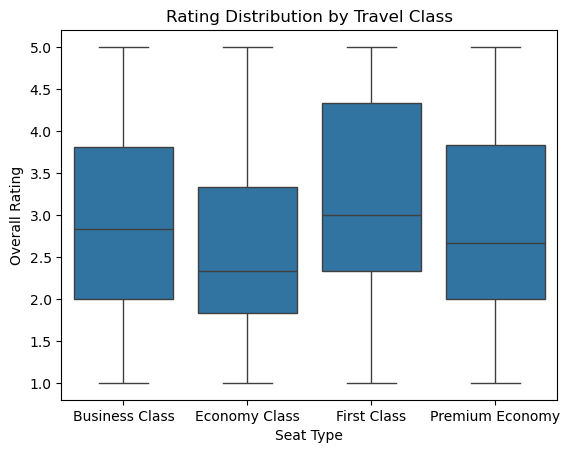

In [25]:
sns.boxplot(x="Seat Type", y="Overall Rating", data=df)
plt.title("Rating Distribution by Travel Class")
plt.show()

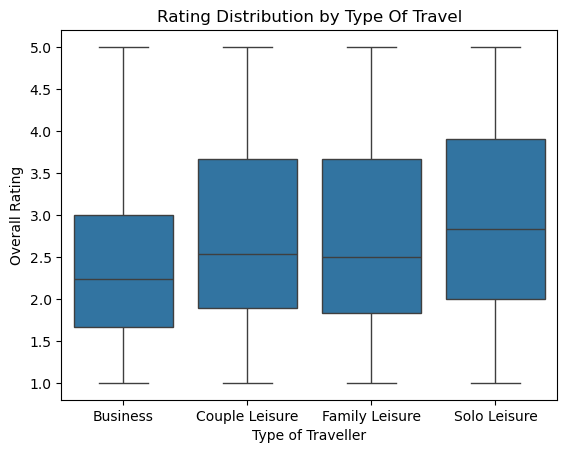

In [26]:
sns.boxplot(x="Type of Traveller", y="Overall Rating", data=df)
plt.title("Rating Distribution by Type Of Travel")
plt.show()


## 12. Route-Level Rating Analysis

Identify the top 30 routes by average overall rating to surface where BA consistently over- or under-delivers.

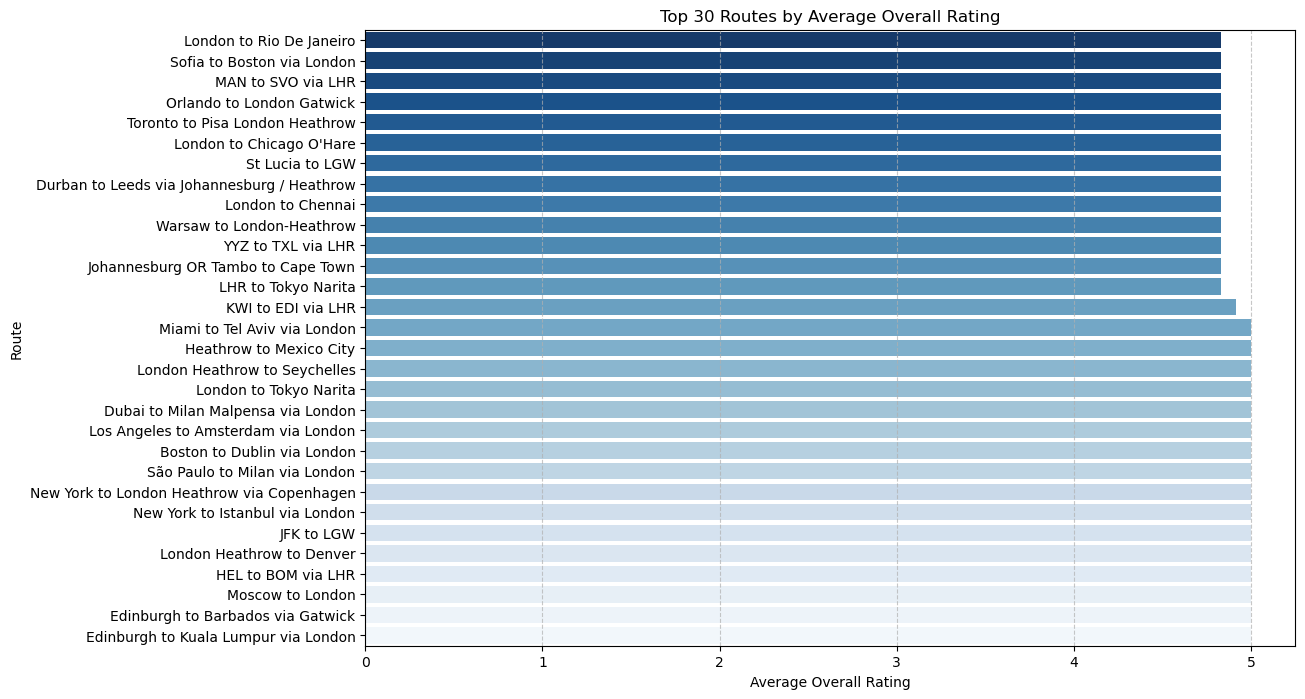

In [27]:
# Compute mean ratings per route and sort
route_ratings = df.groupby('Route')['Overall Rating'].mean().sort_values()

# Select only the top 30 routes to avoid overcrowding
top_routes = route_ratings.tail(30)  

# Plot as a horizontal bar chart
plt.figure(figsize=(12, 8))  # Increase figure size
sns.barplot(
    x=top_routes.values, 
    y=top_routes.index, 
    hue=top_routes.index,  # Assigning hue fixes the warning
    palette="Blues_r", 
    legend=False  # Disable legend as it's not needed
)

# Formatting
plt.xlabel("Average Overall Rating")
plt.ylabel("Route")
plt.title("Top 30 Routes by Average Overall Rating")
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()


## 13. Sentiment Analysis

Two-stage sentiment pipeline:
1. **VADER** (rule-based) — quick compound sentiment score on review titles
2. **Random Forest classifier** — trained on VADER scores + engineered features to predict sentiment class

The trained model is saved to `data/sentiment_model.pkl` for reuse.

> **Dependencies:** `vaderSentiment`, `scikit-learn`, `shap`, `wordcloud` — install with pip if needed.

In [31]:
!pip install vaderSentiment shap --quiet

C:\Users\pants\AppData\Local\Temp\ipykernel_27676\2638071026.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['Airline Popularity'] = df.groupby('Aircraft')['Aircraft'].transform('count')


Model training complete!
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       191
           1       1.00      1.00      1.00       257
           2       1.00      1.00      1.00       181

    accuracy                           1.00       629
   macro avg       1.00      1.00      1.00       629
weighted avg       1.00      1.00      1.00       629

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Model saved successfully!


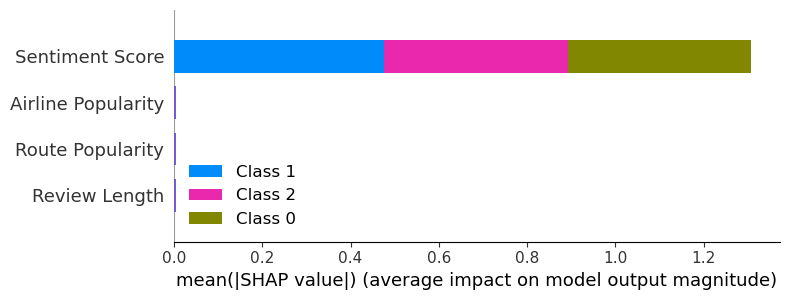

In [32]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
import pickle
import shap

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to compute sentiment score using VADER
def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))  # Ensure text is a string
    return scores['compound']  # Compound score measures overall sentiment

# Apply VADER sentiment analysis
df['Sentiment Score'] = df['Review Title'].apply(get_sentiment)

# Classify sentiment based on VADER's compound score
df['Sentiment'] = df['Sentiment Score'].apply(lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))

# Review Length
df['Review Length'] = df['Review Title'].apply(lambda x: len(str(x).split()))

# Route Popularity
df['Route Popularity'] = df.groupby('Route')['Route'].transform('count')

# Airline Popularity
df['Airline Popularity'] = df.groupby('Aircraft')['Aircraft'].transform('count')

# Check new features
df.head()

# Encode categorical variables (Convert sentiment labels to numbers)
df['Sentiment'] = LabelEncoder().fit_transform(df['Sentiment'])

# Select features and target
X = df[['Sentiment Score', 'Review Length', 'Route Popularity', 'Airline Popularity']]
y = df['Sentiment']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")

# Predictions
y_pred = model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print(classification_report(y_test, y_pred))

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

# Save the trained model
with open("sentiment_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

# SHAP explanation with additivity check disabled
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test, check_additivity=False)

shap.summary_plot(shap_values, X_test)



In [36]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import re

def preprocess_text(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Remove special characters
    return text.lower()

df['clean_review'] = df['Review Title'].apply(preprocess_text)

# Convert text data into a document-term matrix
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
doc_term_matrix = vectorizer.fit_transform(df['clean_review'])

# Apply LDA
lda = LatentDirichletAllocation(n_components=3, random_state=42)  # Extract 3 topics
lda.fit(doc_term_matrix)

# Display topics
def print_topics(model, vectorizer, top_n=10):
    words = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(model.components_):
        print(f"Topic {idx + 1}: {', '.join([words[i] for i in topic.argsort()[:-top_n - 1:-1]])}")

print_topics(lda, vectorizer)


Topic 1: flight, service, experience, good, food, worst, class, business, poor, ba
Topic 2: airline, service, seats, staff, seat, cost, budget, money, low, uncomfortable
Topic 3: british, airways, customer, ba, review, crew, cabin, fly, friendly, recommend


In [34]:
!pip install wordcloud matplotlib

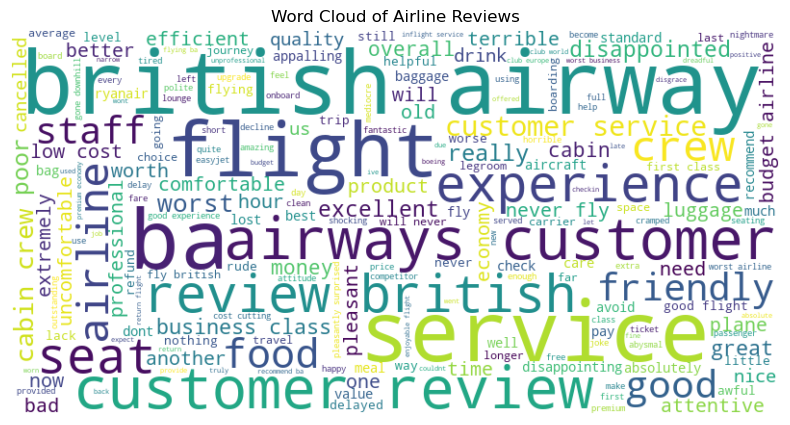

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all reviews into a single text
all_reviews = " ".join(df['clean_review'])

# Create and display the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Airline Reviews")
plt.show()


In [38]:

df.to_csv("data/reviews.csv", index=False)  # Saves without index column


In [39]:
import pickle

# Note: `model` is the RandomForestClassifier trained in the cell above (Cell 41).
# Ensure that cell has been run before executing this one.
with open("data/sentiment_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully in the 'data' folder!")


Model saved successfully in the 'data' folder!


In [40]:
df = pd.read_csv("data/reviews.csv")


In [41]:
df.head()

,Review Title,Aircraft,Type of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food Beverages,Inflight Entertainment,...,Overall Rating,sentiment_score,sentiment_label,Sentiment Score,Sentiment,Review Length,Route Popularity,Airline Popularity,clean_review,Aircraft_Label
0,"""managed to get everything right""",Boeing 777,Business,Premium Economy,Gatwick to Antigua,2025-03-01,5.0,5.0,4.000000,4.000000,...,4.666667,0.0000,Neutral,0.0000,1,5,3,452,managed to get everything right,145
1,"""The seats were excellent""",Boeing 777-200,Couple Leisure,Premium Economy,Mumbai to London,2025-02-01,5.0,4.0,3.000000,5.000000,...,4.333333,0.5719,Positive,0.5719,2,4,6,171,the seats were excellent,157
2,"""the crew were awful""",A350,Couple Leisure,Business Class,Nairobi to London,2025-02-01,4.0,1.0,2.000000,3.000000,...,2.833333,-0.4588,Negative,-0.4588,0,4,2,39,the crew were awful,79
3,"""not use British Airways on this route""",A320,Solo Leisure,Economy Class,London Gatwick to Marrakech,2025-02-01,4.0,1.0,2.709195,2.636533,...,2.390955,0.0000,Neutral,0.0000,1,7,1,662,not use british airways on this route,26
4,"""they still haven't replied""",Boeing 777-300,Business,Premium Economy,Amsterdam to Las Vegas via London,2024-11-01,3.0,3.0,3.000000,3.000000,...,2.333333,0.0000,Neutral,0.0000,1,4,1,54,they still havent replied,167


---
## Lounge Eligibility Lookup Table – BA Heathrow Terminal 3

British Airways operates several lounge tiers at Heathrow Terminal 3. The table below shows who qualifies for each tier:

| Lounge Tier | Who Qualifies |
|---|---|
| **First Lounge** | First Class passengers |
| **Club World Lounge** | Business Class passengers |
| **Galleries Club** | Premium Economy passengers + Gold/Silver Executive Club card holders |
| **Galleries Lounge** | Economy passengers with Gold Executive Club or oneworld Emerald/Sapphire status |

**Objective:** Use the scraped review data to classify routes into meaningful flight groups, estimate seat class distribution per group, and produce a lounge eligibility percentage lookup table for BA's Airport Planning team.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/reviews.csv')

# ── Route Classification ──
def classify_route(route):
    """Classify a route string into a broad flight group based on destination."""
    route = str(route).lower()

    if any(x in route for x in ['new york', 'los angeles', 'chicago', 'boston', 'miami',
                                   'dallas', 'san francisco', 'washington', 'seattle',
                                   'toronto', 'vancouver', 'montreal', 'las vegas',
                                   'houston', 'orlando', 'philadelphia']):
        return 'North America (Long-Haul)'

    elif any(x in route for x in ['dubai', 'abu dhabi', 'doha', 'riyadh', 'kuwait',
                                    'bahrain', 'muscat', 'jeddah', 'amman', 'beirut']):
        return 'Middle East (Long-Haul)'

    elif any(x in route for x in ['hong kong', 'tokyo', 'singapore', 'beijing', 'shanghai',
                                    'bangkok', 'kuala lumpur', 'jakarta', 'seoul', 'osaka',
                                    'taipei', 'manila']):
        return 'Asia Pacific (Long-Haul)'

    elif any(x in route for x in ['johannesburg', 'cape town', 'nairobi', 'lagos',
                                    'accra', 'dar es salaam', 'addis ababa', 'cairo',
                                    'casablanca', 'entebbe', 'harare']):
        return 'Africa (Long-Haul)'

    elif any(x in route for x in ['mumbai', 'delhi', 'bangalore', 'hyderabad',
                                    'chennai', 'kolkata', 'islamabad', 'karachi',
                                    'lahore', 'dhaka', 'kathmandu', 'colombo']):
        return 'Indian Subcontinent (Long-Haul)'

    elif any(x in route for x in ['são paulo', 'buenos aires', 'santiago', 'bogota',
                                    'lima', 'rio', 'mexico city', 'cancun', 'havana',
                                    'kingston', 'bridgetown', 'nassau', 'antigua',
                                    'barbados', 'trinidad', 'tobago', 'st lucia', 'montego']):
        return 'Caribbean & Latin America (Long-Haul)'

    elif any(x in route for x in ['sydney', 'melbourne', 'perth', 'brisbane', 'auckland']):
        return 'Australia & Pacific (Ultra Long-Haul)'

    elif any(x in route for x in ['paris', 'amsterdam', 'frankfurt', 'madrid', 'barcelona',
                                    'rome', 'milan', 'zurich', 'vienna', 'brussels',
                                    'geneva', 'lisbon', 'athens', 'stockholm', 'oslo',
                                    'copenhagen', 'helsinki', 'warsaw', 'prague', 'budapest',
                                    'dublin', 'edinburgh', 'glasgow', 'manchester', 'nice',
                                    'venice', 'berlin', 'munich', 'dusseldorf', 'hamburg',
                                    'lyon', 'malaga', 'tenerife', 'palma', 'marrakech',
                                    'alicante', 'faro', 'jersey', 'guernsey', 'gibraltar']):
        return 'Europe (Short/Medium-Haul)'

    else:
        return 'Other / Unclassified'


df['Route Group'] = df['Route'].apply(classify_route)

print('Route Group Distribution:')
print(df['Route Group'].value_counts())
print(f"\nUnclassified routes: {(df['Route Group'] == 'Other / Unclassified').sum()}")

Route Group Distribution:
Route Group
Other / Unclassified                     1348
Europe (Short/Medium-Haul)                638
North America (Long-Haul)                 546
Asia Pacific (Long-Haul)                  203
Africa (Long-Haul)                        151
Caribbean & Latin America (Long-Haul)     110
Middle East (Long-Haul)                    84
Indian Subcontinent (Long-Haul)            54
Australia & Pacific (Ultra Long-Haul)       7
Name: count, dtype: int64

Unclassified routes: 1348


In [43]:
# Standardise seat type labels
seat_map = {
    'First Class': 'First',
    'Business Class': 'Business',
    'Premium Economy': 'Premium Economy',
    'Economy Class': 'Economy'
}
df['Seat Class'] = df['Seat Type'].map(seat_map).fillna(df['Seat Type'])

# Calculate % distribution of seat classes by route group
seat_dist = (
    df.groupby(['Route Group', 'Seat Class'])
    .size()
    .unstack(fill_value=0)
)
seat_pct = seat_dist.div(seat_dist.sum(axis=1), axis=0) * 100
seat_pct = seat_pct.round(1)

print('Seat Class Distribution (%) by Route Group:')
print(seat_pct)

Seat Class Distribution (%) by Route Group:
Seat Class                             Business  Economy  First  \
Route Group                                                       
Africa (Long-Haul)                         39.7     46.4    6.0   
Asia Pacific (Long-Haul)                   33.0     45.8    6.9   
Australia & Pacific (Ultra Long-Haul)      28.6     57.1   14.3   
Caribbean & Latin America (Long-Haul)      43.6     36.4    4.5   
Europe (Short/Medium-Haul)                 29.9     67.4    0.6   
Indian Subcontinent (Long-Haul)            24.1     48.1    5.6   
Middle East (Long-Haul)                    33.3     41.7    9.5   
North America (Long-Haul)                  28.6     50.2    6.6   
Other / Unclassified                       30.4     54.5    6.2   

Seat Class                             Premium Economy  
Route Group                                             
Africa (Long-Haul)                                 7.9  
Asia Pacific (Long-Haul)                       

### Lounge Eligibility Assumptions

Since the review dataset captures **seat class** but not loyalty tier, we apply the following proxy assumptions — grounded in BA's Executive Club structure and industry benchmarks:

| Lounge | Eligibility Rule Applied |
|---|---|
| **First Lounge** | 100% of First Class passengers |
| **Club World** | 100% of Business Class passengers |
| **Galleries Club** | 100% of Premium Economy passengers |
| **Galleries Lounge (Economy Gold)** | ~15% of Economy on **long-haul** routes; ~5% on **short-haul** |

> **Rationale for loyalty proxies:** BA's Executive Club has millions of members, but Gold/Silver tier (which grants lounge access) represents a small fraction. On high-volume long-haul routes like North America and Asia Pacific, industry data suggests 8–15% of economy passengers hold premium loyalty status. On European short-haul routes, this drops to ~5% as premium cabin uptake is lower and business travellers more often book Club Europe directly.

In [46]:
def estimate_lounge_eligibility(row, route_group):
    """Estimate lounge eligibility % for each tier given seat class mix."""
    first_pct   = row.get('First', 0)
    biz_pct     = row.get('Business', 0)
    pe_pct      = row.get('Premium Economy', 0)
    econ_pct    = row.get('Economy', 0)

    # Loyalty status proxy: % of Economy passengers with lounge-qualifying status
    is_longhaul = route_group not in ['Europe (Short/Medium-Haul)', 'Other / Unclassified']
    loyalty_rate = 0.15 if is_longhaul else 0.05

    first_lounge    = first_pct
    club_world      = biz_pct
    galleries_club  = pe_pct  # Premium Economy always eligible for Galleries Club
    eco_gold        = econ_pct * loyalty_rate  # Economy passengers with Gold card
    total_eligible  = first_lounge + club_world + galleries_club + eco_gold

    return {
        'First Lounge (%)':                  round(first_lounge, 1),
        'Club World Lounge (%)':             round(club_world, 1),
        'Galleries Club (%)':                round(galleries_club, 1),
        'Galleries Lounge – Eco Gold (%)':   round(eco_gold, 1),
        'Total Lounge Eligible (%)':         round(total_eligible, 1)
    }


# Build the lookup table
lookup_rows = []
for route_group, row in seat_pct.iterrows():
    entry = {'Route Group': route_group}
    # Add seat class mix columns for transparency
    for cls in ['First', 'Business', 'Premium Economy', 'Economy']:
        entry[f'{cls} Mix (%)'] = row.get(cls, 0)
    entry.update(estimate_lounge_eligibility(row, route_group))
    lookup_rows.append(entry)

lookup_table = pd.DataFrame(lookup_rows).set_index('Route Group')

print('BA HEATHROW T3 – LOUNGE ELIGIBILITY LOOKUP TABLE')
print('=' * 70)
print(lookup_table.to_string())

# Save to CSV
lookup_table.to_csv('data/lounge_lookup_table.csv')
print('\nLookup table saved to data/lounge_lookup_table.csv')

BA HEATHROW T3 – LOUNGE ELIGIBILITY LOOKUP TABLE
                                       First Mix (%)  Business Mix (%)  Premium Economy Mix (%)  Economy Mix (%)  First Lounge (%)  Club World Lounge (%)  Galleries Club (%)  Galleries Lounge – Eco Gold (%)  Total Lounge Eligible (%)
Route Group                                                                                                                                                                                                                              
Africa (Long-Haul)                               6.0              39.7                      7.9             46.4               6.0                   39.7                 7.9                              7.0                       60.6
Asia Pacific (Long-Haul)                         6.9              33.0                     14.3             45.8               6.9                   33.0                14.3                              6.9                       61.1
Australia & Pac

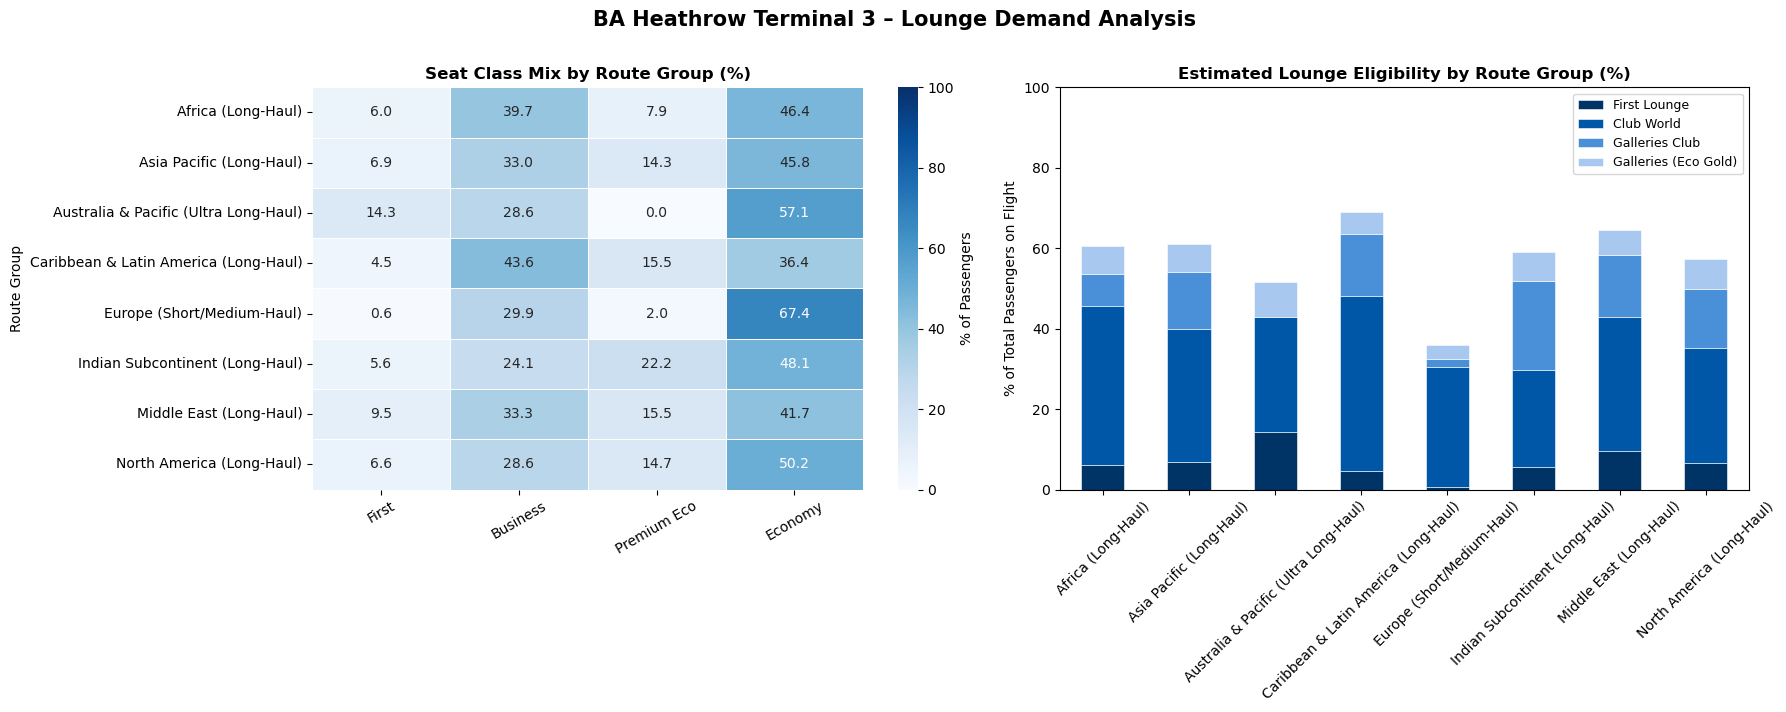

Chart saved to data/lounge_eligibility_chart.png


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('BA Heathrow Terminal 3 – Lounge Demand Analysis', fontsize=15, fontweight='bold', y=1.01)

# ── Plot 1: Seat class mix heatmap ──
heat_data = lookup_table[['First Mix (%)', 'Business Mix (%)',
                            'Premium Economy Mix (%)', 'Economy Mix (%)']].copy()
heat_data = heat_data[heat_data.index != 'Other / Unclassified']
heat_data.columns = ['First', 'Business', 'Premium Eco', 'Economy']

sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='Blues',
            ax=axes[0], linewidths=0.5, cbar_kws={'label': '% of Passengers'},
            vmin=0, vmax=100)
axes[0].set_title('Seat Class Mix by Route Group (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# ── Plot 2: Lounge eligibility stacked bar ──
bar_data = lookup_table[['First Lounge (%)', 'Club World Lounge (%)',
                          'Galleries Club (%)', 'Galleries Lounge – Eco Gold (%)']].copy()
bar_data = bar_data[bar_data.index != 'Other / Unclassified']
bar_data.columns = ['First Lounge', 'Club World', 'Galleries Club', 'Galleries (Eco Gold)']

bar_data.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#003366', '#0057a8', '#4a90d9', '#a8c8f0'],
              edgecolor='white', linewidth=0.4)
axes[1].set_title('Estimated Lounge Eligibility by Route Group (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% of Total Passengers on Flight')
axes[1].set_xlabel('')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('data/lounge_eligibility_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to data/lounge_eligibility_chart.png')

### How to Use This Lookup Table

The Airport Planning team can apply this table as follows:

**Step 1:** Identify the route group for a planned flight (e.g. LHR–JFK → *North America (Long-Haul)*)

**Step 2:** Obtain the expected passenger load for the departure (e.g. 280 passengers on a Boeing 777)

**Step 3:** Multiply total passengers by each lounge eligibility % to estimate headcount:

```
Example – LHR to JFK, 280 passengers:
  First Lounge:       280 × First Lounge (%)    = estimated First pax
  Club World:         280 × Club World (%)      = estimated Business pax
  Galleries Club:     280 × Galleries Club (%)  = estimated Premium Eco pax
  Galleries (Eco Gold): 280 × Eco Gold (%)      = estimated loyalty pax
```

**Step 4:** Aggregate across all flights in a given departure window (e.g. 06:00–10:00) to forecast peak lounge demand.

> **Note:** These percentages are data-driven estimates based on scraped passenger review data and loyalty proxy assumptions. As BA's actual fleet and schedule data becomes available, the `classify_route()` function and loyalty rate assumptions can be updated to improve precision.